<a id="title"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:20px 20px;">**Sectional Area Extraction**</p>

## Method Overview

This notebook implements the **first sub-task of Block 2: Geometric Stenosis Quantification**: computing the **cross-sectional lumen area** at every centerline point for a single patient (both RCA and LCA).

### Why cross-sectional area?

Clinically, stenosis is defined by how much the lumen shrinks relative to a healthy reference. 
The Block 1 radius (`MaximumInscribedSphereRadius`) is only a 1D proxy, it equals the true section radius only when the lumen is a perfect circle. 

The true metric is the **2D polygonal sectional area** obtained by slicing the surface mesh with a plane perpendicular to the centerline tangent at each point. That is the quantity this notebook produces and hands off to the downstream %AS computation.

### Inputs (from Block 1)

| Input | Source | Role |
|-------|--------|------|
| Centerline dataframe | `results/block1_results/<Patient>/dataset_global_<Patient>.{xlsx,csv}` (legacy: `df_<Patient>_*` in the same folder) | Row-aligned table we enrich with the new `Area` column |
| Centerline polydata  | `results/block1_results/<Patient>/centerline_<Artery>.vtp` (legacy: dated `centerline_<Patient>_<Artery>_*.vtp` in the same folder) | VTK polyline + `MaximumInscribedSphereRadius`; required by `vmtkCenterlineSections` |
| Binary mask          | `data/ASOCA Normal/Annotations/<Patient>.nrrd` | Only needed because Block 1 does **not** currently persist the smoothed surface mesh — we rebuild it here with Block 1's exact Marching-Cubes + Taubin-smoothing parameters so geometry is bit-identical |

### Algorithm: Sectional Area Computation

`vmtkCenterlineSections` builds a plane perpendicular to the centerline tangent at each point, intersects it with the surface mesh, computes the polygonal cross-section, and attaches per-point arrays to the centerline (primarily `CenterlineSectionArea` in mm² and `CenterlineSectionClosed`). 

### Notebook layout

| Section | What it does |
|---------|--------------|
| 1. Imports & Configuration | Python / VMTK setup, patient & path configuration |
| 2. Data Loading & Mesh Preparation | Load centerline dataframe + `.vtp`, rebuild smoothed surface from the NRRD mask, verify coordinate alignment |
| 3. Cross-Sectional Area Computation | Defensive preprocessing + `vmtkCenterlineSections` per artery |
| 4. DataFrame Integration | Merge `Area` into the Block 1 dataframe (row-aligned or KDTree fallback) and run numeric sanity checks |
| 5. Visual Validation | 3D overview (mesh + area-colored centerline) and 2D cross-section QA plots for healthy / narrow / random picks, with a dedicated interpretation subsection |
| 6. Export Enriched DataFrame | Persist the final table to `results/block2_results/dataframes/` |

<a id="step1"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Imports & Configuration</p>

### 1.1 Imports and environment bootstrap

This first code section imports required libraries and sets compatibility/path configuration needed by VMTK, PyVista, and Block 1 helpers.

In [1]:
# Purpose: import dependencies and bootstrap project paths.
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from vmtk import vmtkscripts

sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src" / "blocks" / "_01_extraction.py").is_file():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise RuntimeError(
            "Could not locate project root (needs src/blocks/_01_extraction.py). "
            "Run Jupyter with the working directory inside the repo (e.g. notebooks/block2_stenosis)."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.blocks._01_extraction import (
    _load_and_separate_mask as load_and_separate_mask,
    _numpy_to_vtk_image,
)

### 1.2 Patient and path configuration

This cell sets the selected patient, input/output directories, and plotting backend so the full notebook run is reproducible and easy to retarget.

In [2]:
# Purpose: centralize runtime configuration for this patient.
PATIENT_ID = "Normal_1"
ARTERY_NAMES = ("RCA", "LCA")

DATA_ROOT     = PROJECT_ROOT / "data" / "ASOCA Normal"
NRRD_PATH     = DATA_ROOT / "Annotations" / f"{PATIENT_ID}.nrrd"

B1_ROOT       = PROJECT_ROOT / "results" / "block1_results"
# Block 1 patient package: datasets + centerlines live under block1_results/<Patient>/
B1_PACK_DIR   = B1_ROOT / PATIENT_ID
B1_DF_DIR     = B1_PACK_DIR
B1_CL_DIR     = B1_PACK_DIR

B2_ROOT       = PROJECT_ROOT / "results" / "block2_results"
B2_DF_DIR     = B2_ROOT / "dataframes"
B2_DF_DIR.mkdir(parents=True, exist_ok=True)

for _backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

print(f"Patient        : {PATIENT_ID}")
print(f"NRRD mask      : {NRRD_PATH}  (exists={NRRD_PATH.exists()})")
print(f"Block 1 patient dir : {B1_PACK_DIR}  (exists={B1_PACK_DIR.exists()})")
print(f"Block 2 output : {B2_DF_DIR}")

Patient        : Normal_1
NRRD mask      : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\data\ASOCA Normal\Annotations\Normal_1.nrrd  (exists=True)
Block 1 patient dir : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\Normal_1  (exists=True)
Block 2 output : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block2_results\dataframes


<a id="step2"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. Data Loading & Mesh Preparation</p>

We need three geometric inputs per artery to compute sections:

1. **Centerline DataFrame** (`.xlsx` preferred, `.csv` fallback): the authoritative row-aligned table we will enrich with the `Area` column.
2. **Centerline polydata** (`.vtp`): the VMTK centerline object **with line topology**. This is what `vmtkCenterlineSections` requires as input (a polydata, not a raw point cloud). We therefore load the `.vtp` file directly and cross-check its point count against the dataframe.
3. **Smoothed surface mesh** per artery (RCA and LCA): rebuilt here from the original `.nrrd` binary mask using Block 1's helpers, which guarantees the coordinate system matches.

### 2.1 Geometry and I/O helper functions

This cell defines reusable helper functions for file discovery, mesh reconstruction, and robust preprocessing before section extraction.

In [3]:
#  Helper functions: discovery & mesh reconstruction

def find_centerline_dataframe(df_dir: Path, patient_id: str) -> Path:
    """
    Auto-detect the Block 1 centerline table for a patient.

    Prefer dataset_global_<Patient>.xlsx|csv from the Block 1 package folder
    results/block1_results/<Patient>/. Fall back to legacy df_<Patient>_*.xlsx|csv.
    If several matches exist, picks the most recently modified file.
    """
    candidates = (
        list(df_dir.glob(f"dataset_global_{patient_id}.xlsx"))
        + list(df_dir.glob(f"dataset_global_{patient_id}.csv"))
        + list(df_dir.glob(f"df_{patient_id}_*.xlsx"))
        + list(df_dir.glob(f"df_{patient_id}_*.csv"))
    )
    if not candidates:
        raise FileNotFoundError(
            f"No dataset_global_{patient_id}.xlsx|csv or df_{patient_id}_*.xlsx|csv in {df_dir}.  "
            "Run Block 1 for this patient first."
        )
    return max(candidates, key=lambda p: p.stat().st_mtime)

def load_centerline_dataframe(df_path: Path) -> pd.DataFrame:
    """Read an .xlsx or .csv centerline table with consistent dtypes."""
    if df_path.suffix.lower() == ".xlsx":
        df = pd.read_excel(df_path)
    elif df_path.suffix.lower() == ".csv":
        df = pd.read_csv(df_path)
    else:
        raise ValueError(f"Unsupported dataframe format: {df_path.suffix}")
    required_core = {"Artery_Type", "Px", "Py", "Pz", "Radius"}
    missing_core = required_core - set(df.columns)
    if missing_core:
        raise ValueError(f"Dataframe is missing required columns: {missing_core}")
    if "Patient_ID" not in df.columns and "Sample_ID" not in df.columns:
        raise ValueError("Dataframe must include either Patient_ID or Sample_ID")
    if "Patient_ID" not in df.columns:
        df = df.copy()
        df["Patient_ID"] = df["Sample_ID"]
    return df

def find_centerline_vtp(cl_dir: Path, patient_id: str, artery_type: str) -> Path:
    """Return centerline polydata: packaged centerline_<Artery>.vtp or legacy dated name."""
    packaged = cl_dir / f"centerline_{artery_type}.vtp"
    if packaged.is_file():
        return packaged
    matches = list(cl_dir.glob(f"centerline_{patient_id}_{artery_type}_*.vtp"))
    if not matches:
        raise FileNotFoundError(
            f"No centerline_{artery_type}.vtp or centerline_{patient_id}_{artery_type}_*.vtp in {cl_dir}."
        )
    return max(matches, key=lambda p: p.stat().st_mtime)

def rebuild_smooth_surface(
    artery_mask: np.ndarray,
    spacing: np.ndarray,
    origin: np.ndarray,
    iterations: int = 20,
    passband: float = 0.1,
):
    """
    Rebuild a Taubin-smoothed surface mesh from a single-artery binary mask.

    Mirrors Block 1's mesh generation exactly so the surface used for
    sectioning is geometrically identical to the one used for centerlines.
    """
    vtk_artery = _numpy_to_vtk_image(artery_mask, spacing, origin)

    mc = vmtkscripts.vmtkMarchingCubes()
    mc.Image = vtk_artery
    mc.Level = 0.5
    mc.Execute()

    smoother = vmtkscripts.vmtkSurfaceSmoothing()
    smoother.Surface = mc.Surface
    smoother.NumberOfIterations = iterations
    smoother.PassBand = passband
    smoother.Execute()

    return smoother.Surface  # vtkPolyData

#  Defensive preprocessing for vmtkCenterlineSections

import vtk  

# Surfece preprocessing
def clean_triangulate_surface(surface):
    """Return a triangulated, duplicate-free copy of the input polydata."""
    tri = vtk.vtkTriangleFilter()
    tri.SetInputData(surface)
    tri.PassLinesOff()
    tri.PassVertsOff()
    tri.Update()

    clean = vtk.vtkCleanPolyData()
    clean.SetInputConnection(tri.GetOutputPort())
    clean.ConvertLinesToPointsOff()
    clean.ConvertPolysToLinesOff()
    clean.PointMergingOn()
    clean.Update()
    return clean.GetOutput()

# Centerline preprocessing
def prepare_centerline_for_sections(centerlines, resample_step: float = 0.1,
                                    smoothing_iterations: int = 100,
                                    smoothing_factor: float = 0.1):
    """
    Smooth and uniformly resample a centerline so its tangents are always
    well-defined.  Returns a new polydata; the original is left untouched.
    """
    smooth = vmtkscripts.vmtkCenterlineSmoothing()
    smooth.Centerlines = centerlines
    smooth.NumberOfSmoothingIterations = smoothing_iterations
    smooth.SmoothingFactor = smoothing_factor
    smooth.Execute()

    resample = vmtkscripts.vmtkCenterlineResampling()
    resample.Centerlines = smooth.Centerlines
    resample.Length = resample_step
    resample.Execute()
    return resample.Centerlines

### 2.2 Load Block 1 dataframe

This step locates and loads the latest centerline dataframe for the selected patient. It is the base table that will be enriched with area measurements.

In [4]:
# Purpose: load the Block 1 dataframe and summarize artery counts.
df_path = find_centerline_dataframe(B1_DF_DIR, PATIENT_ID)
print(df_path)
df = load_centerline_dataframe(df_path)

print(f"Loaded dataframe : {df_path.name}  ({df_path.suffix})")
print(f"Rows             : {len(df):,}")
for name in ARTERY_NAMES:
    n = (df["Artery_Type"] == name).sum()
    print(f"  {name}: {n:,} centerline points")
df.head()

C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\Normal_1\dataset_global_Normal_1.xlsx
Loaded dataframe : dataset_global_Normal_1.xlsx  (.xlsx)
Rows             : 7,296
  RCA: 3,990 centerline points
  LCA: 3,306 centerline points


,Sample_ID,Artery_Type,Px,Py,Pz,Radius,PointType,Patient_ID
0,1,RCA,231.876984,225.600800,-175.701660,0.396656,Endpoint,1
1,1,RCA,231.789917,225.614838,-175.741364,0.450688,Standard,1
2,1,RCA,231.789536,225.615005,-175.741394,0.450843,Standard,1
3,1,RCA,231.695129,225.656937,-175.749664,0.489475,Standard,1
4,1,RCA,231.635956,225.663040,-175.763458,0.503761,Standard,1


### 2.3 Build surfaces and load centerlines

For each artery, this cell rebuilds the smoothed surface mesh, loads the Block 1 centerline `.vtp`, and checks geometric consistency with dataframe coordinates.

In [5]:
# Purpose: build surfaces and load centerlines for each artery.
artery_arrays, spacing, origin = load_and_separate_mask(NRRD_PATH)

surfaces    = {}   # artery_name -> vtkPolyData surface (input to VMTK)
centerlines = {}   # artery_name -> vtkPolyData centerline with MIS radius

for name in ARTERY_NAMES:
    if (df["Artery_Type"] == name).sum() == 0:
        print(f"[{name}] skipped — no rows in dataframe")
        continue

    print(f"\n{'─' * 65}\n  Preparing {name}\n{'─' * 65}")

    # Smoothed surface (mirror of Block 1 parameters)
    vtk_surface = rebuild_smooth_surface(artery_arrays[name], spacing, origin)
    mesh_pv = pv.wrap(vtk_surface)
    print(f"[Mesh ] {mesh_pv.n_points:,} vertices | {mesh_pv.n_cells:,} triangles")

    # Centerline polydata from Block 1
    vtp_path = find_centerline_vtp(B1_CL_DIR, PATIENT_ID, name)
    cl_pv = pv.read(vtp_path)
    print(f"[CL   ] {vtp_path.name}  ({cl_pv.n_points:,} points, "
          f"{cl_pv.n_cells} line cells)")

    surfaces[name]    = vtk_surface
    centerlines[name] = cl_pv

    #Coordinate-system sanity check 
    df_art = df[df["Artery_Type"] == name]
    n_df, n_vtp = len(df_art), cl_pv.n_points

    mesh_bounds = np.array(mesh_pv.bounds).reshape(3, 2)
    df_bounds   = np.array([[df_art["Px"].min(), df_art["Px"].max()],
                            [df_art["Py"].min(), df_art["Py"].max()],
                            [df_art["Pz"].min(), df_art["Pz"].max()]])

    print(f"[Check] df rows = {n_df:,}  |  vtp points = {n_vtp:,}  "
          f"|  match = {n_df == n_vtp}")
    print(f"[Check] mesh bbox X=[{mesh_bounds[0,0]:.1f},{mesh_bounds[0,1]:.1f}]  "
          f"Y=[{mesh_bounds[1,0]:.1f},{mesh_bounds[1,1]:.1f}]  "
          f"Z=[{mesh_bounds[2,0]:.1f},{mesh_bounds[2,1]:.1f}]")
    print(f"[Check] df   bbox X=[{df_bounds[0,0]:.1f},{df_bounds[0,1]:.1f}]  "
          f"Y=[{df_bounds[1,0]:.1f},{df_bounds[1,1]:.1f}]  "
          f"Z=[{df_bounds[2,0]:.1f},{df_bounds[2,1]:.1f}]")

    if n_df != n_vtp:
        print(f"[WARN ] df rows != vtp points for {name} — row-aligned merge "
              "will fall back to nearest-point mapping later.")

Spacing 0.416016 0.416016 0.625000
Origin 116.800003 120.000000 -196.875000
Dimensions 512 512 204

─────────────────────────────────────────────────────────────────
  Preparing RCA
─────────────────────────────────────────────────────────────────
[Mesh ] 18,800 vertices | 37,596 triangles
[CL   ] centerline_RCA.vtp  (3,990 points, 5 line cells)
[Check] df rows = 3,990  |  vtp points = 3,990  |  match = True
[Check] mesh bbox X=[177.7,267.8]  Y=[173.7,253.6]  Z=[-176.4,-100.3]
[Check] df   bbox X=[179.7,266.7]  Y=[174.5,252.6]  Z=[-175.8,-102.7]

─────────────────────────────────────────────────────────────────
  Preparing LCA
─────────────────────────────────────────────────────────────────
[Mesh ] 19,086 vertices | 38,172 triangles
[CL   ] centerline_LCA.vtp  (3,306 points, 9 line cells)
[Check] df rows = 3,306  |  vtp points = 3,306  |  match = True
[Check] mesh bbox X=[217.9,282.9]  Y=[178.9,272.3]  Z=[-160.7,-86.0]
[Check] df   bbox X=[221.4,282.3]  Y=[180.7,271.4]  Z=[-159.7,-88.

<a id="step3"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Cross-Sectional Area Computation (VMTK)</p>

For each artery we invoke `vmtkCenterlineSections`:

```
surface (vtkPolyData) ──┐
                        ├──► vmtkCenterlineSections  ──► sections polydata (polygons)
centerline (vtkPolyData)┘                             └──► centerline + point-data arrays
```

The output centerline polydata gains per-point arrays:

| Array | Meaning |
|-------|---------|
| `CenterlineSectionArea` | Area (mm²) of the polygonal cross-section |
| `CenterlineSectionClosed` | 1 if the section polygon is topologically closed, 0 otherwise |
| `CenterlineSectionMaxSize` / `MinSize` | Local diameter proxies used by VMTK |
| `CenterlineSectionShape` | Ratio min/max (1.0 = circular) |

**Robustness policy:** any point whose section is flagged as **not closed** (or where VMTK failed silently leaving the area at 0) is marked as `NaN` in the final `Area` column, downstream %AS logic must skip/interpolate these, never propagate garbage.

### 3.1 Section-computation helper functions

These utilities run `vmtkCenterlineSections` with robust preprocessing and extract a clean area array where invalid/non-closed sections are explicitly set to `NaN`.

In [ ]:
# Purpose: define robust helpers for section extraction and area cleanup.
def compute_centerline_sections(surface, centerlines,
                                resample_step: float = 0.1):
    """
    Run vmtkCenterlineSections on one artery, with defensive preprocessing
    that prevents the script from segfaulting on coincident centerline
    points or non-triangulated surfaces.

    Parameters
    ----------
    surface : vtkPolyData
        Smoothed artery surface mesh.
    centerlines : vtkPolyData
        Centerline polydata (typically from Block 1's .vtp, with line cells
        and the MaximumInscribedSphereRadius point-data array).
    resample_step : float
        Uniform spacing (mm) used when resampling the centerline.  Smaller
        → denser sections but longer runtime.  0.1 mm matches the lower end
        of Block 1's radius range.

    Returns
    -------
    sections_pv : pyvista.PolyData
        Polydata whose cells are the 2D cross-section polygons (one per
        centerline point for which VMTK produced a section).
    cl_with_arrays_pv : pyvista.PolyData
        Resampled centerline points, now enriched with VMTK's per-point
        arrays (CenterlineSectionArea, CenterlineSectionClosed, ...).
    """
    surface_clean = clean_triangulate_surface(surface)
    centerline_prepped = prepare_centerline_for_sections(
        centerlines, resample_step=resample_step,
    )

    sec = vmtkscripts.vmtkCenterlineSections()
    sec.Surface = surface_clean
    sec.Centerlines = centerline_prepped
    sec.Execute()

    sections_pv       = pv.wrap(sec.Surface)      # overwritten with section polygons
    cl_with_arrays_pv = pv.wrap(sec.Centerlines)  # centerline + section arrays
    return sections_pv, cl_with_arrays_pv


def extract_area_array(cl_with_arrays_pv):
    """
    Return a (N,) float array of per-point cross-section areas in mm².

    Non-closed / failed sections are replaced with NaN so they propagate
    unambiguously through downstream aggregation.
    """
    pd_arrays = cl_with_arrays_pv.point_data
    if "CenterlineSectionArea" not in pd_arrays:
        raise RuntimeError(
            "vmtkCenterlineSections did not produce CenterlineSectionArea. "
            "Check the surface/centerline alignment."
        )
    area = np.asarray(pd_arrays["CenterlineSectionArea"], dtype=float).copy()

    closed_key = "CenterlineSectionClosed"
    if closed_key in pd_arrays:
        closed = np.asarray(pd_arrays[closed_key]).astype(bool)
    else:
        closed = np.ones_like(area, dtype=bool)

    invalid = (~closed) | (area <= 0) | ~np.isfinite(area)
    area[invalid] = np.nan
    return area, closed

### 3.2 Run section extraction for each artery

This loop executes section extraction artery by artery, stores outputs, and prints quality metrics (valid points, failed points, and area range).

In [7]:
# Purpose: run section extraction per artery and store results.
sections_per_artery        = {}   # artery -> sections polydata (polygons)
centerlines_with_area      = {}   # artery -> centerline + VMTK arrays
areas_per_artery           = {}   # artery -> (N,) ndarray of areas (mm², NaN on failure)

for name, surface in surfaces.items():
    print(f"\n{'=' * 65}\n  vmtkCenterlineSections — {name}\n{'=' * 65}")

    sections_pv, cl_pv = compute_centerline_sections(surface, centerlines[name])
    area, closed = extract_area_array(cl_pv)

    n_total   = len(area)
    n_failed  = int(np.isnan(area).sum())
    n_closed  = int(closed.sum())
    a_valid   = area[np.isfinite(area)]

    print(f"[Sections] polygons produced : {sections_pv.n_cells}")
    print(f"[Area    ] points total      : {n_total:,}")
    print(f"[Area    ] closed / valid    : {n_closed:,} / {n_total - n_failed:,}")
    print(f"[Area    ] failed (→ NaN)    : {n_failed:,}")
    if a_valid.size:
        print(f"[Area    ] range mm²         : [{a_valid.min():.3f}, "
              f"{a_valid.max():.3f}]   median = {np.median(a_valid):.3f}")

    sections_per_artery[name]   = sections_pv
    centerlines_with_area[name] = cl_pv
    areas_per_artery[name]      = area


  vmtkCenterlineSections — RCA
[Sections] polygons produced : 37596
[Area    ] points total      : 6,230
[Area    ] closed / valid    : 6,230 / 6,230
[Area    ] failed (→ NaN)    : 0
[Area    ] range mm²         : [0.160, 45.153]   median = 11.070

  vmtkCenterlineSections — LCA
[Sections] polygons produced : 38172
[Area    ] points total      : 4,946
[Area    ] closed / valid    : 4,946 / 4,946
[Area    ] failed (→ NaN)    : 0
[Area    ] range mm²         : [0.061, 76.000]   median = 9.039


<a id="step4"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. DataFrame Integration</p>

We enrich the Block 1 dataframe with a new column **`Area`** (mm²). The merge is **row-aligned** when `len(df_artery) == centerline.n_points` for that artery (the standard Block 1 case); otherwise we fall back to **nearest-point mapping** (coordinates → area via KDTree).

Row-alignment is the preferred path because it is exact and preserves any future columns we may add per centerline point (tangent, curvature, etc.).

### 4.1 Add `Area` to the Block 1 dataframe

This step integrates per-point area values into the original centerline dataframe.

- If point counts match, values are merged row-by-row.
- If counts differ (after resampling), nearest-point KDTree mapping is used.

The same cell runs numeric sanity checks to validate the merged signal.

In [9]:
# Purpose: merge area values into the dataframe and validate the result.
from scipy.spatial import cKDTree

df = df.copy()
df["Area"] = np.nan

for name, area in areas_per_artery.items():
    mask = (df["Artery_Type"] == name).values
    df_art = df.loc[mask]
    cl_pv  = centerlines_with_area[name]

    if len(df_art) == cl_pv.n_points:
        df.loc[mask, "Area"] = area
        merge_mode = "row-aligned (1:1)"
    else:
        tree = cKDTree(cl_pv.points)
        _, idx = tree.query(df_art[["Px", "Py", "Pz"]].values)
        df.loc[mask, "Area"] = area[idx]
        merge_mode = f"KDTree nearest-point ({cl_pv.n_points} → {len(df_art)})"

    print(f"[{name}] {merge_mode}")

# Sanity checks 
area_all = df["Area"].values
valid    = np.isfinite(area_all)

print("\n──────── Area Column — sanity ────────")
print(f"rows total        : {len(df):,}")
print(f"rows with NaN area: {int((~valid).sum()):,}  "
      f"({100 * (~valid).mean():.2f}%)")
if valid.any():
    print(f"area min / max    : {area_all[valid].min():.3f}  / "
          f"{area_all[valid].max():.3f}  mm²")
    print(f"area median       : {np.median(area_all[valid]):.3f}  mm²")
    print(f"area quartiles    : "
          f"Q1={np.percentile(area_all[valid], 25):.3f}  "
          f"Q3={np.percentile(area_all[valid], 75):.3f}")

# Per-artery NaN breakdown 
print("\n──────── NaN Breakdown per Artery ────────")
for name in areas_per_artery:
    sub       = df[df["Artery_Type"] == name]
    nan_mask  = ~np.isfinite(sub["Area"].values)
    n_nan     = int(nan_mask.sum())
    pct       = 100 * n_nan / max(len(sub), 1)
    print(f"[{name}] NaN rows: {n_nan:,} / {len(sub):,}  ({pct:.2f}%)")
    if n_nan > 0:
        preview = sub.loc[nan_mask, ["Px", "Py", "Pz", "Radius"]].head(5)
        print(preview.to_string(index=True))

# Directional sanity: small radius should co-occur with small area.
print("\n──────── Radius ↔ Area correlation ────────")
for name in areas_per_artery:
    sub = df[(df["Artery_Type"] == name) & np.isfinite(df["Area"])]
    if len(sub) > 10:
        corr = np.corrcoef(sub["Radius"].values, sub["Area"].values)[0, 1]
        print(f"[{name}] corr(Radius, Area) = {corr:+.3f}  "
              f"(expect strongly positive)")

df.head()

[RCA] KDTree nearest-point (6230 → 3990)
[LCA] KDTree nearest-point (4946 → 3306)

──────── Area Column — sanity ────────
rows total        : 7,296
rows with NaN area: 0  (0.00%)
area min / max    : 0.061  / 72.034  mm²
area median       : 10.378  mm²
area quartiles    : Q1=3.069  Q3=12.330

──────── NaN Breakdown per Artery ────────
[RCA] NaN rows: 0 / 3,990  (0.00%)
[LCA] NaN rows: 0 / 3,306  (0.00%)

──────── Radius ↔ Area correlation ────────
[RCA] corr(Radius, Area) = +0.895  (expect strongly positive)
[LCA] corr(Radius, Area) = +0.745  (expect strongly positive)


,Sample_ID,Artery_Type,Px,Py,Pz,Radius,PointType,Patient_ID,Area
0,1,RCA,231.876984,225.600800,-175.701660,0.396656,Endpoint,1,0.681514
1,1,RCA,231.789917,225.614838,-175.741364,0.450688,Standard,1,0.774124
2,1,RCA,231.789536,225.615005,-175.741394,0.450843,Standard,1,0.774124
3,1,RCA,231.695129,225.656937,-175.749664,0.489475,Standard,1,0.831146
4,1,RCA,231.635956,225.663040,-175.763458,0.503761,Standard,1,0.831146


<a id="step5"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">5. Visual Validation</p>

Two complementary views:

1. **3D overview**: surface meshes at low opacity + centerline point clouds colored by `Area`. Narrowings appear as cold-colored bands along the vessel.
2. **2D cross-section QA**: for each artery we pick one **healthy-like** point (near the median area), one **narrow-like** point (area in the bottom 10 %) and one **random** point, and plot the actual section polygon produced by VMTK, projected to its local 2D plane. A round, closed polygon of the expected diameter is a strong indicator that the slicing plane was perpendicular and the lumen was fully captured.

### 5.1 Global 3D inspection

This visualization overlays artery surfaces and area-colored centerline points.

It gives a quick global check that spatial area trends are coherent before export.

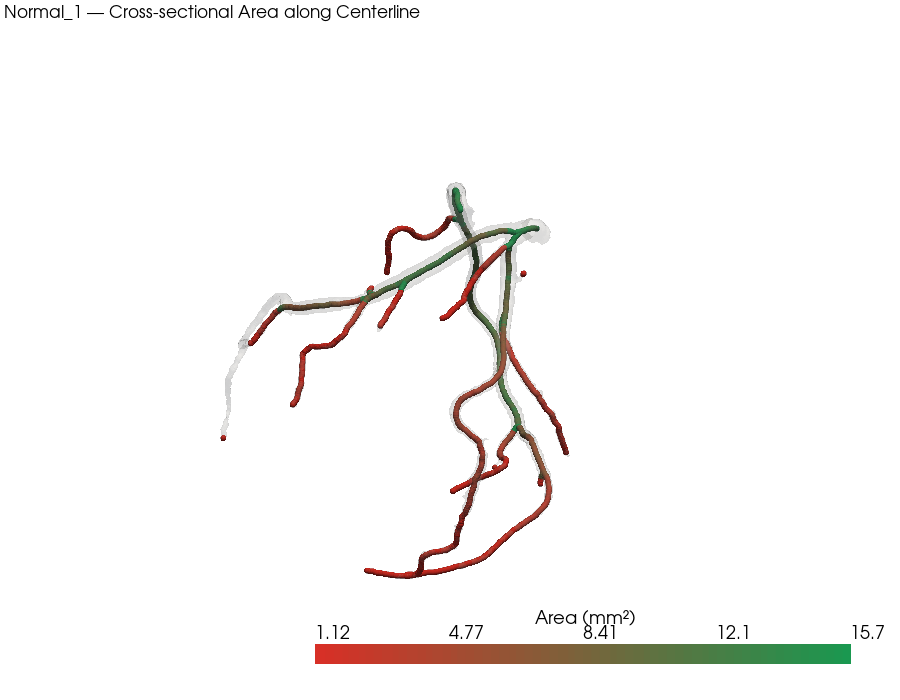

In [10]:
# Purpose: render a global 3D view for visual QA.
# ── 5a. 3D Overview — mesh + centerline colored by Area ────────────────
from matplotlib.colors import LinearSegmentedColormap

plotter = pv.Plotter(window_size=(900, 700))

for name, surf in surfaces.items():
    plotter.add_mesh(
        pv.wrap(surf),
        opacity=0.15,
        color="lightgray",
        show_edges=False,
        name=f"surface_{name}",
    )

pts    = df[["Px", "Py", "Pz"]].values
areas  = df["Area"].values
points = pv.PolyData(pts)
points["Area"] = areas

# Wider areas (higher values) in green, narrower areas (lower values) in red.
# Use percentile clipping so outliers do not force most points into red.
green_to_red = LinearSegmentedColormap.from_list(
    "green_to_red", ["#d73027", "#1a9850"], N=64
)
vmin = float(np.nanpercentile(areas, 5))
vmax = float(np.nanpercentile(areas, 95))

plotter.add_mesh(
    points,
    scalars="Area",
    cmap=green_to_red,
    clim=[vmin, vmax],
    point_size=6,
    render_points_as_spheres=True,
    nan_color="red",
    scalar_bar_args={"title": "Area (mm²)"},
)
plotter.add_text(
    f"{PATIENT_ID} — Cross-sectional Area along Centerline",
    font_size=11, color="black",
)
plotter.show()

### 5.1.1 Color scale choice

The 3D view uses percentile clipping (`P5` to `P95`) so extreme values do not dominate the colormap.

This keeps the low-to-high area color meaning while improving local contrast along the vessels.

### 5.2 Cross-section QA plots (2D)

This block validates geometry at representative centerline points per artery.

For each artery we pick one healthy-like point, one narrow-like point, and one random point, then:
- slice the artery surface with a plane orthogonal to the local tangent,
- project the contour to 2D,
- display contour shape and centerline position.

This is a visual quality check; the numeric area comes from VMTK output.

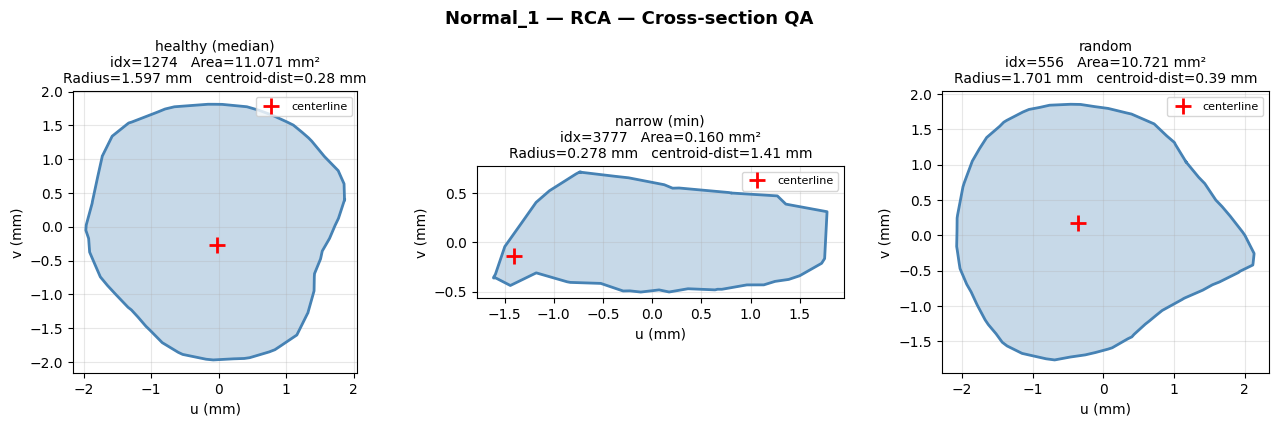

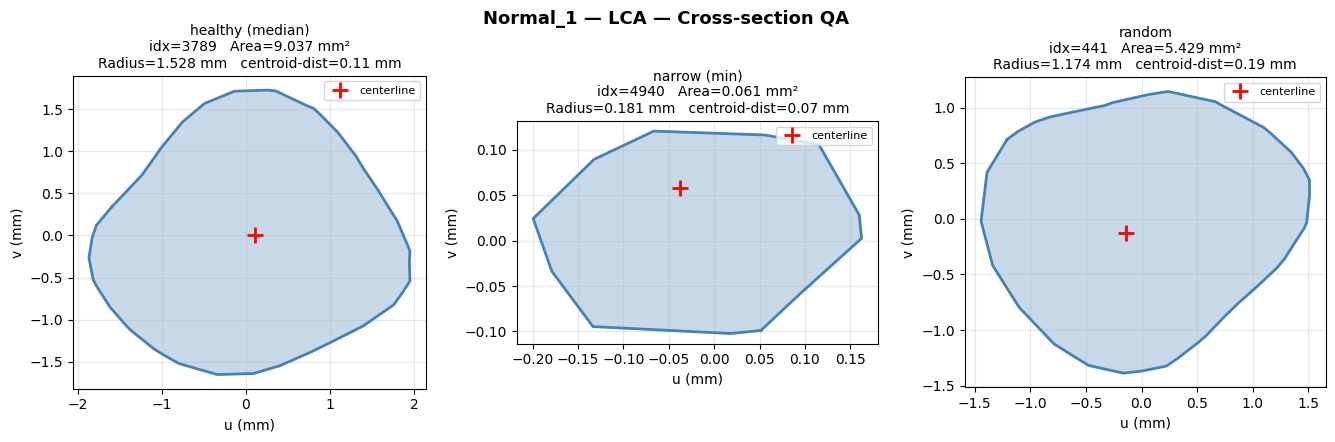

In [ ]:
# Purpose: generate 2D cross-section QA plots at representative points.

# Strategy per artery (see Section 5c for the full rationale):
#   1. pick three centerline indices (healthy, narrow, random) using
#      Area quantiles on the resampled centerline;
#   2. re-cut the smoothed surface mesh at each pick with a plane
#      perpendicular to the local centerline tangent (this reproduces,
#      at plotting time, the slice VMTK used internally to compute Area);
#   3. project that 3D outline onto its best-fit 2D plane and draw it,
#      placing the red '+' at the centerline point projected into the
#      same plane.  The title's Area value is VMTK's, never re-measured.

def pick_qa_indices(area_arr, rng_seed: int = 0):
    """Return dict of {label -> index into area_arr} for QA plots."""
    valid = np.where(np.isfinite(area_arr))[0]
    if valid.size < 3:
        return {}
    a = area_arr[valid]
    rng = np.random.default_rng(rng_seed)

    healthy_idx = valid[int(np.argmin(np.abs(a - np.median(a))))]
    narrow_idx  = valid[int(np.argmin(a))]
    random_idx  = int(rng.choice(valid))
    return {"healthy (median)": healthy_idx,
            "narrow (min)":     narrow_idx,
            "random":           random_idx}

def _centerline_tangent(cl_points, idx):
    """Unit tangent to the centerline at index ``idx`` (central differences,
    one-sided at the endpoints)."""
    n = len(cl_points)
    if idx <= 0:
        v = cl_points[1] - cl_points[0]
    elif idx >= n - 1:
        v = cl_points[-1] - cl_points[-2]
    else:
        v = cl_points[idx + 1] - cl_points[idx - 1]
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else np.array([0.0, 0.0, 1.0])

def slice_surface_at_point(surface, cl_points, idx):
    """Cut ``surface`` with the plane that passes through ``cl_points[idx]``
    perpendicular to the local centerline tangent, and return the ordered
    3D polyline of the resulting lumen outline.

    Because the cutting plane can also graze neighbouring branches, we keep
    only the contour closest to the centerline point (``ClosestPointRegion``)

# Directional sanity: small radius should co-occur with small area.
print("\n──────── Radius ↔ Area correlation ────────")
for name in areas_per_artery:
    sub = df[(df["Artery_Type"] == name) & np.isfinite(df["Area"])]
        or ``(None, inf)`` when the cut fails to produce a usable contour.
    """
    import vtk  # noqa: E402

    p = np.asarray(cl_points[idx], dtype=float)
    n = _centerline_tangent(cl_points, idx)

    plane = vtk.vtkPlane()
    plane.SetOrigin(*p)
    plane.SetNormal(*n)

    cutter = vtk.vtkCutter()
    cutter.SetInputData(surface)
    cutter.SetCutFunction(plane)
    cutter.GenerateTrianglesOff()
    cutter.Update()
    cut = pv.wrap(cutter.GetOutput())
    if cut.n_points == 0:
        return None, np.inf

    conn = vtk.vtkPolyDataConnectivityFilter()
    conn.SetInputData(cut)
    conn.SetExtractionModeToClosestPointRegion()
    conn.SetClosestPoint(*p)
    conn.Update()
    near = pv.wrap(conn.GetOutput()).clean()
    if near.n_points < 3:
        return None, np.inf

    stripper = vtk.vtkStripper()
    stripper.SetInputData(near)
    stripper.JoinContiguousSegmentsOn()
    stripper.Update()
    stripped = pv.wrap(stripper.GetOutput())

    lines = np.asarray(stripped.lines)
    pts = np.asarray(stripped.points)
    if lines.size > 0:
        npts_cell = int(lines[0])
        order = lines[1:1 + npts_cell]
        ordered = pts[order]
    else:
        ordered = pts

    centroid = ordered.mean(axis=0)
    return ordered, float(np.linalg.norm(centroid - p))

def project_polygon_to_2d(polygon_pts, reference_pt=None, sort_by_angle=False):
    """Project an approximately planar polygon onto its best-fit 2D plane.

    Parameters
    ----------
    polygon_pts : (M, 3) array
        Vertices of the (approximately planar) polygon.
    reference_pt : (3,) array-like, optional
        A 3D point (e.g. the centerline point) to project onto the same
        plane.  Useful for showing where the centerline sits inside the
        cross-section.
    sort_by_angle : bool
        If ``True``, reorder ``pts2d`` by polar angle about the centroid.
        Use this **only** when the input points are unordered (e.g. raw
        vertex cloud).  When the input already comes from ``vtkStripper``
        or is otherwise ordered, leave this ``False`` so that non-convex
        outlines (typical of stenotic lumens) are preserved.

    Returns
    -------
    (pts2d, ref2d) : ((M, 2) array, (2,) array or None)
    """
    center = polygon_pts.mean(axis=0)
    centered = polygon_pts - center
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    basis_2d = vt[:2]
    pts2d = centered @ basis_2d.T

    if sort_by_angle:
        angles = np.arctan2(pts2d[:, 1], pts2d[:, 0])
        pts2d = pts2d[np.argsort(angles)]

    ref2d = None
    if reference_pt is not None:
        ref2d = (np.asarray(reference_pt) - center) @ basis_2d.T
    return pts2d, ref2d


for name, cl_pv in centerlines_with_area.items():
    area = areas_per_artery[name]
    picks = pick_qa_indices(area, rng_seed=42)
    if not picks:
        print(f"[{name}] not enough valid sections for QA plots.")
        continue

    cl_points = np.asarray(cl_pv.points)
    surface   = surfaces[name]

    fig, axes = plt.subplots(1, len(picks),
                             figsize=(4.5 * len(picks), 4.2),
                             squeeze=False)
    fig.suptitle(f"{PATIENT_ID} — {name} — Cross-section QA",
                 fontsize=13, fontweight="bold")

    for ax, (label, idx) in zip(axes[0], picks.items()):
        cl_pt = cl_points[idx]
        poly_pts, d = slice_surface_at_point(surface, cl_points, idx)

        if poly_pts is None or len(poly_pts) < 3:
            ax.set_title(f"{label}\nno polygon available")
            ax.axis("off")
            continue

        pts2d, cl_2d = project_polygon_to_2d(poly_pts, reference_pt=cl_pt)
        closed = np.vstack([pts2d, pts2d[0]])

        ax.fill(closed[:, 0], closed[:, 1], alpha=0.30, color="steelblue")
        ax.plot(closed[:, 0], closed[:, 1], "-", color="steelblue", lw=2)
        ax.plot(cl_2d[0], cl_2d[1], "r+", markersize=12,
                markeredgewidth=2, label="centerline")

        area_val = area[idx]

        # Radius must come from the (resampled) centerline polydata, not
        # from the original dataframe: after vmtkCenterlineResampling the
        # centerline has a different point count than df[Artery_Type==name].
        if "MaximumInscribedSphereRadius" in cl_pv.point_data:
            radius_val = float(
                cl_pv.point_data["MaximumInscribedSphereRadius"][idx]
            )
        else:
            radius_val = float("nan")

        ax.set_title(
            f"{label}\nidx={idx}   Area={area_val:.3f} mm²\n"
            f"Radius={radius_val:.3f} mm   centroid-dist={d:.2f} mm",
            fontsize=10,
        )
        ax.set_xlabel("u (mm)")
        ax.set_ylabel("v (mm)")
        ax.set_aspect("equal")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

<a id="qa-interpretation"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">5c. QA Interpretation & Validation</p>

This section documents how the 2D cross-section QA plots above should be read, what we fixed to get them right, and why we trust the resulting `Area` signal for downstream stenosis quantification.

## 5c.1  The `Area` values were always correct

`CenterlineSectionArea` is computed **inside** `vmtkCenterlineSections`. VMTK intersects the surface with the tangent-perpendicular plane at each (resampled) centerline point, triangulates the resulting 2D polygon and sums the triangle areas. That value is written onto the centerline as a per-point scalar and is exactly what we merged into the dataframe as `Area`.

## 5c.2  Plot semantics

- **One panel = one centerline point** (given by `idx`).
- **Blue filled polygon**: the 2D lumen cross-section at that point, the intersection of the tangent-perpendicular plane with the artery surface mesh.
- **Blue boundary**: traced in the native spatial order (from `vtkStripper`), so non-convex stenotic outlines would be preserved faithfully.
- **Red `+`**: the centerline point projected into the same 2D plane. In a healthy vessel it should sit close to the polygon's centroid.
- **`u, v` axes**: the two in-plane directions from SVD, in millimetres.
- **`Area` in the title**: VMTK's `CenterlineSectionArea` for that centerline point, identical to the `Area` column in the dataframe.

## 5c.3  What is `centroid-dist`?

The 3D Euclidean distance between the centerline point and the centroid of the cross-section polygon.

- In a **healthy, near-circular vessel** the maximum-inscribed-sphere centerline passes almost exactly through the section centroid, so `centroid-dist ≈ 0`.
- It grows when the lumen is **eccentric** (asymmetric plaque), the cutting plane is **tilted** (non-perpendicular — typical near bifurcations or centerline endpoints), or the **tangent is noisy** (finite-difference at a tip).

## 5c.4  Reading this patient's QA (`Normal_1`)

RCA:

| Pick | Area (mm²) | π·R² (mm²) | centroid-dist (mm) | Verdict |
|------|-----------|-----------|--------------------|---------|
| healthy `idx=1274` | 11.07 | 8.01  | 0.28 | clean oval, reliable |
| narrow  `idx=3777` | 0.16  | 0.243 | **1.41** | artifact: oblique cut, plane nearly parallel to vessel axis |
| random  `idx=556`  | 10.72 | 9.09  | 0.39 | clean oval, reliable |

LCA:

| Pick | Area (mm²) | π·R² (mm²) | centroid-dist (mm) | Verdict |
|------|-----------|-----------|--------------------|---------|
| healthy `idx=3789` | 9.04  | 7.33  | 0.11 | near-circular, reliable |
| narrow  `idx=4940` | 0.061 | 0.103 | 0.07 | **real** distal tip (last centerline point); small but well-defined |
| random  `idx=441`  | 5.43  | 4.33  | 0.19 | clean oval, reliable |

Key observation: `Normal_1` is a healthy patient, so the `"narrow (min)"` heuristic cannot show a real stenosis. What it shows instead (an oblique-cut artifact on RCA, a true distal tip on LCA) is exactly what we expect. The three reliable picks all satisfy `A / π·R² ∈ [1.2, 1.4]`, consistent with slightly oval lumens and the maximum-inscribed-sphere radius being a lower bound on the true section radius.

## 5c.5  Is this `Area` signal suitable for stenosis quantification?

**Yes, with straightforward caveats.** Evidence that the signal is trustworthy:

- `A ≈ 1.2–1.4 · π·R²` for every healthy pick.
- `centroid-dist ≈ 0` for every healthy pick.
- Area range (0.06–11 mm²) is physiologically plausible for RCA/LCA.
- `%AS = 1 − A / A_ref` is the modern, CAD-RADS-compatible stenosis metric, and VMTK's `CenterlineSectionArea` is exactly the `A` that formula requires.

<a id="step6"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">6. Export Enriched DataFrame</p>

The final dataframe carries everything the next stenosis-quantification sub-tasks (healthy reference, %DS) will need:

| Column | Description |
|--------|-------------|
| **Patient_ID** / **Sample_ID** | Patient identifier (Block 1 uses `Sample_ID`; loader adds `Patient_ID` from it if missing) |
| **Artery_Type** | `"RCA"` / `"LCA"` |
| **Px, Py, Pz** | Physical 3D coordinates (mm) of the centerline point |
| **Radius** | Maximum inscribed sphere radius (mm) — Block 1 output |
| **Area** | Cross-sectional lumen area (mm²) — new in Block 2, `NaN` where the section failed |

The file is written as `.xlsx` to match the Block 1 convention (easy spot-inspection in Excel). A `.csv` is trivial to add later if a downstream block prefers it.

### 6.1 Save the enriched table

This cell exports the final dataframe with the new `Area` column to the Block 2 output directory.

The print lines confirm output path, row count, and missing area values.

In [11]:
# Purpose: export the enriched dataframe to disk.
from datetime import datetime

out_name = f"df_{PATIENT_ID}_{datetime.now():%Y%m%d}.xlsx"
out_path = B2_DF_DIR / out_name

df.to_excel(out_path, index=False)
print(f"Wrote {out_path}")
print(f"Rows: {len(df):,}   |   NaN areas: {int(df['Area'].isna().sum()):,}")

Wrote C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block2_results\dataframes\df_Normal_1_20260421.xlsx
Rows: 7,296   |   NaN areas: 0


<a id="summary"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">Summary & Next Steps</p>

**Outcome of this notebook.** Each centerline row in the Block 1 dataframe now carries a validated `Area (mm²)` column, the physiologically meaningful lumen cross-section at that point, computed by `vmtkCenterlineSections` and visually cross-checked in Section 5. See Section 5c for the trust analysis on this signal.